<a href="https://colab.research.google.com/github/Muen1/multilingual-health-qa-africa/blob/main/notebooks/01_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# CELL 0 — Mount Google Drive (run this first in every notebook)
from google.colab import drive
drive.mount('/content/drive')

import os

# Base path — all your project files live here
BASE_DIR  = '/content/drive/MyDrive/multilingual_health_qa'
DATA_DIR  = f'{BASE_DIR}/data'
OUT_DIR   = f'{BASE_DIR}/outputs'
SUB_DIR   = f'{BASE_DIR}/submissions'
PLOT_DIR  = f'{BASE_DIR}/plots'

# Create output folders if they don't exist yet
for d in [OUT_DIR, SUB_DIR, PLOT_DIR]:
    os.makedirs(d, exist_ok=True)

# Verify your data files are visible
print("Files in data folder:")
print(os.listdir(DATA_DIR))

Mounted at /content/drive
Files in data folder:
['Train.csv', 'Val.csv', 'Test.csv', 'SampleSubmission.csv']


In [2]:
# CELL 0 — Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
import os

BASE_DIR = '/content/drive/MyDrive/multilingual_health_qa'
DATA_DIR = f'{BASE_DIR}/data'
PLOT_DIR = f'{BASE_DIR}/plots'
os.makedirs(PLOT_DIR, exist_ok=True)

print("Data files:", os.listdir(DATA_DIR))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data files: ['Train.csv', 'Val.csv', 'Test.csv', 'SampleSubmission.csv']


In [3]:
# CELL 1 — Install and import
!pip install seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
print("Imports done.")

Imports done.


In [4]:
# CELL 2 — Load all data
train = pd.read_csv(f'{DATA_DIR}/Train.csv')
val   = pd.read_csv(f'{DATA_DIR}/Val.csv')
test  = pd.read_csv(f'{DATA_DIR}/Test.csv')

print("Train shape:", train.shape)
print("Val shape:  ", val.shape)
print("Test shape: ", test.shape)
print("\nColumn names:", train.columns.tolist())
train.head(3)

Train shape: (29815, 4)
Val shape:   (6686, 4)
Test shape:  (2618, 3)

Column names: ['ID', 'input', 'output', 'subset']


,ID,input,output,subset
0,ID_TR_Aka_Gha_A3B1799D,Ɔkwan bɛn so na mmabunbɛtumi aboa wɔn mfɛfoɔ a...,Mmabun betumi aboa atipɛnfo a ebia nsa anaa nn...,Aka_Gha
1,ID_TR_Aka_Gha_1C80317F,Edinnsiananmu bɛn na nnipa a ɛsono wɔn bɔbeasu...,"Wɔ Ghana mu no, amanmmra no gye binary gender ...",Aka_Gha
2,ID_TR_Aka_Gha_06671AD1,Ɔkwan bɛn so na ɔbarima ne ɔbea nna a wɔtwe wɔ...,Sɛ wɔtwe wɔn ho fi nna mu anaasɛ wɔtwentwɛn wɔ...,Aka_Gha


In [8]:
# CELL 3 — Auto-detect column names

q_col    = 'input'
a_col    = 'output'
lang_col = 'subset'
id_col   = 'ID'

print(f"Question column : {q_col}")
print(f"Answer column   : {a_col}")
print(f"Language column : {lang_col}")
print(f"ID column       : {id_col}")

Question column : input
Answer column   : output
Language column : subset
ID column       : ID


In [7]:
print(train.columns)

Index(['ID', 'input', 'output', 'subset'], dtype='object')


In [9]:
# CELL 4 — Basic data quality checks
print("=== NULL VALUES — TRAIN ===")
print(train.isnull().sum())

print("\n=== DUPLICATE ROWS ===")
print(f"Train duplicates: {train.duplicated().sum()}")
print(f"Val duplicates:   {val.duplicated().sum()}")

print("\n=== DATA TYPES ===")
print(train.dtypes)

=== NULL VALUES — TRAIN ===
ID        0
input     0
output    0
subset    0
dtype: int64

=== DUPLICATE ROWS ===
Train duplicates: 0
Val duplicates:   0

=== DATA TYPES ===
ID        object
input     object
output    object
subset    object
dtype: object


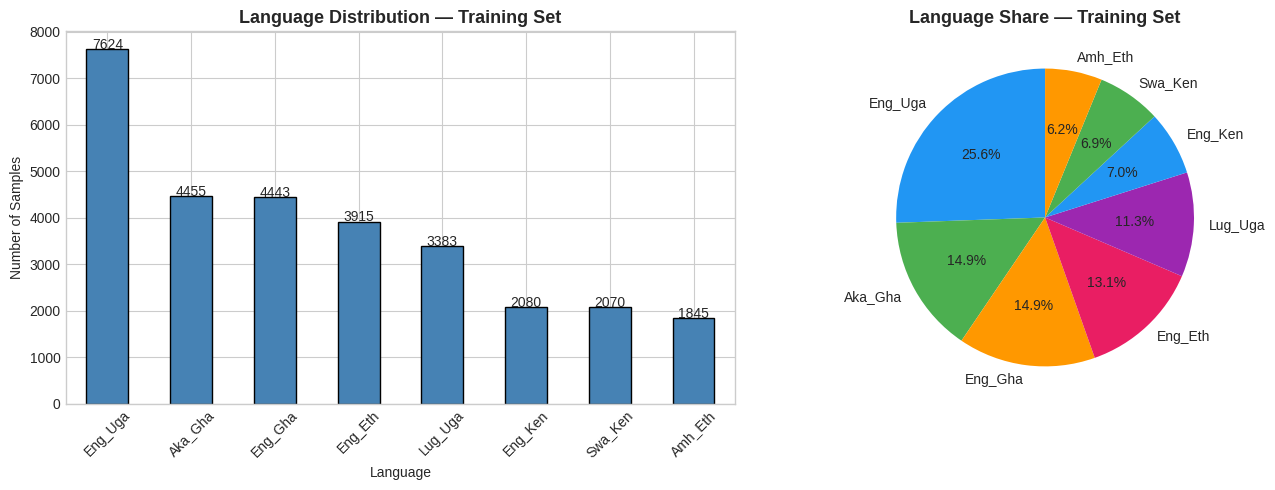

Saved to: /content/drive/MyDrive/multilingual_health_qa/plots/language_distribution.png
subset
Eng_Uga    7624
Aka_Gha    4455
Eng_Gha    4443
Eng_Eth    3915
Lug_Uga    3383
Eng_Ken    2080
Swa_Ken    2070
Amh_Eth    1845
Name: count, dtype: int64


In [10]:
# CELL 5 — Language distribution (save plot for report)
lang_counts = train[lang_col].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

lang_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Language Distribution — Training Set', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Language')
axes[0].set_ylabel('Number of Samples')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(lang_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontsize=10)

lang_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90,
                 colors=['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0'])
axes[1].set_title('Language Share — Training Set', fontsize=13, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
save_path = f'{PLOT_DIR}/language_distribution.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to: {save_path}")
print(lang_counts)

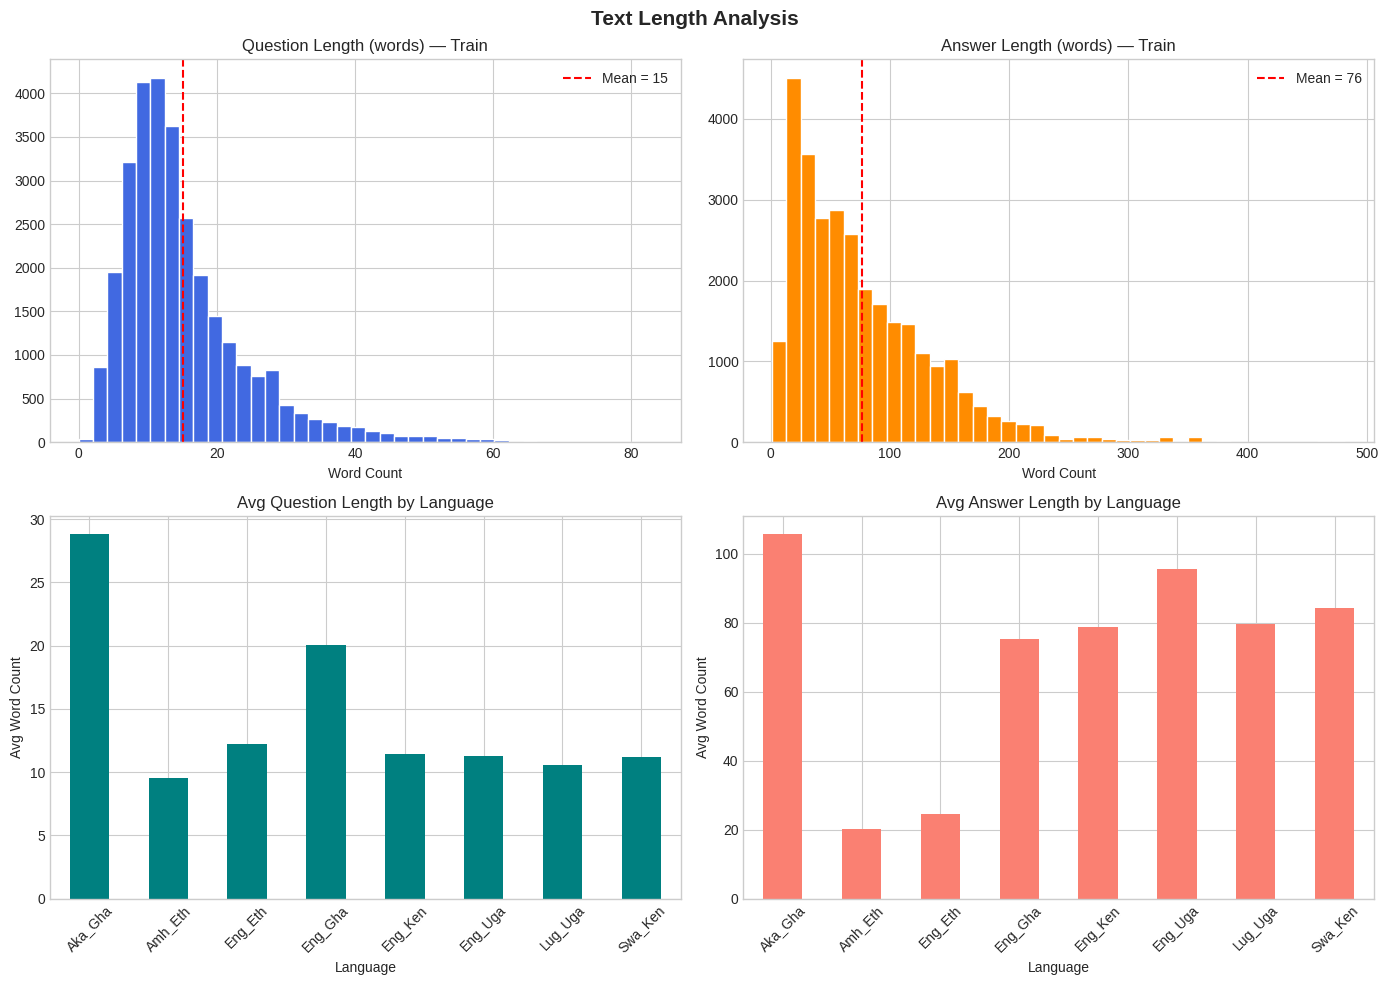

Saved to: /content/drive/MyDrive/multilingual_health_qa/plots/length_analysis.png


In [11]:
# CELL 6 — Text length analysis
train['q_len'] = train[q_col].astype(str).apply(lambda x: len(x.split()))
train['a_len'] = train[a_col].astype(str).apply(lambda x: len(x.split()))
val['q_len']   = val[q_col].astype(str).apply(lambda x: len(x.split()))
val['a_len']   = val[a_col].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Text Length Analysis', fontsize=15, fontweight='bold')

train['q_len'].hist(bins=40, ax=axes[0,0], color='royalblue', edgecolor='white')
axes[0,0].axvline(train['q_len'].mean(), color='red', linestyle='--',
                  label=f"Mean = {train['q_len'].mean():.0f}")
axes[0,0].set_title('Question Length (words) — Train')
axes[0,0].set_xlabel('Word Count')
axes[0,0].legend()

train['a_len'].hist(bins=40, ax=axes[0,1], color='darkorange', edgecolor='white')
axes[0,1].axvline(train['a_len'].mean(), color='red', linestyle='--',
                  label=f"Mean = {train['a_len'].mean():.0f}")
axes[0,1].set_title('Answer Length (words) — Train')
axes[0,1].set_xlabel('Word Count')
axes[0,1].legend()

train.groupby(lang_col)['q_len'].mean().plot(kind='bar', ax=axes[1,0], color='teal')
axes[1,0].set_title('Avg Question Length by Language')
axes[1,0].set_xlabel('Language')
axes[1,0].set_ylabel('Avg Word Count')
axes[1,0].tick_params(axis='x', rotation=45)

train.groupby(lang_col)['a_len'].mean().plot(kind='bar', ax=axes[1,1], color='salmon')
axes[1,1].set_title('Avg Answer Length by Language')
axes[1,1].set_xlabel('Language')
axes[1,1].set_ylabel('Avg Word Count')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
save_path = f'{PLOT_DIR}/length_analysis.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to: {save_path}")

In [12]:
# CELL 7 — Per-language statistics table (copy into your report)
lang_stats = train.groupby(lang_col).agg(
    count=(q_col, 'count'),
    avg_q_len=('q_len', 'mean'),
    avg_a_len=('a_len', 'mean'),
    max_q_len=('q_len', 'max'),
    max_a_len=('a_len', 'max')
).round(1)

print("=== PER-LANGUAGE STATISTICS ===")
print(lang_stats.to_string())

=== PER-LANGUAGE STATISTICS ===
         count  avg_q_len  avg_a_len  max_q_len  max_a_len
subset                                                    
Aka_Gha   4455       28.8      105.6         83        458
Amh_Eth   1845        9.5       20.2         23        106
Eng_Eth   3915       12.2       24.5         29        118
Eng_Gha   4443       20.0       75.1         48        408
Eng_Ken   2080       11.4       78.7         43        315
Eng_Uga   7624       11.2       95.4         55        482
Lug_Uga   3383       10.5       79.7         40        331
Swa_Ken   2070       11.2       84.3         43        345


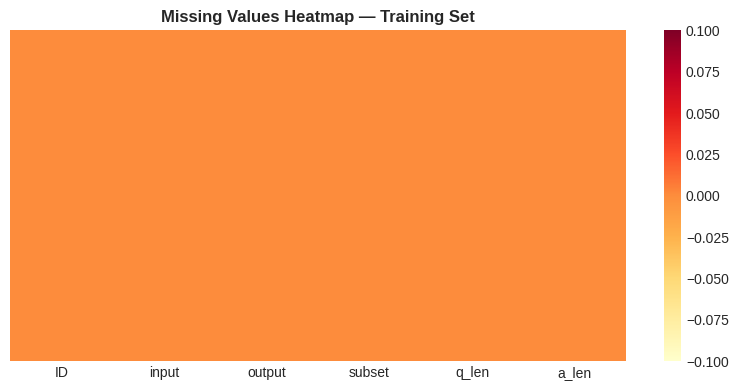

Saved to: /content/drive/MyDrive/multilingual_health_qa/plots/missing_values.png


In [13]:
# CELL 8 — Missing value heatmap
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(train.isnull(), yticklabels=False, cmap='YlOrRd', cbar=True, ax=ax)
ax.set_title('Missing Values Heatmap — Training Set', fontsize=12, fontweight='bold')
plt.tight_layout()
save_path = f'{PLOT_DIR}/missing_values.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to: {save_path}")

In [14]:
# CELL 9 — Sample one example per language (qualitative understanding)
print("=== ONE SAMPLE PER LANGUAGE ===")
for lang in sorted(train[lang_col].unique()):
    row = train[train[lang_col] == lang].iloc[0]
    print(f"\n{'─'*60}")
    print(f"Language : {lang}")
    print(f"Question : {str(row[q_col])[:300]}")
    print(f"Answer   : {str(row[a_col])[:300]}")

=== ONE SAMPLE PER LANGUAGE ===

────────────────────────────────────────────────────────────
Language : Aka_Gha
Question : Ɔkwan bɛn so na mmabunbɛtumi aboa wɔn mfɛfoɔ a nsa anaa nnubɔne ama wɔayɛ wɔn ayayadeɛ? Yei bi ne sɛnea wɔbɛkyekye wɔn werɛ, sɛnea wɔbɛboa wɔn ma wɔanya mmoa firi nnwumakuo a ɛfata hɔ, ne sɛnea wɔbɛsiw afɔbu suban ne nsɛm a nkurɔfoɔ de gu oyarefoɔ no so no kwan.
Answer   : Mmabun betumi aboa atipɛnfo a ebia nsa anaa nnubɔne ama wɔayɛ wɔn ayayadeɛ so denam: Nkate fam mmoa a wɔde bɛma na wɔagye wɔn nkate atom a wɔremmu atɛn anaasɛ wɔmfa asodi nto wɔn so. Wɔn a wɔbɛhyɛ wɔn nkuran ma wɔakɔhwehwɛ ayaresa na wɔanya mmoa nnwuma te sɛ afotu, telefon a wɔde frɛ nkurɔfo wɔ ɔhaw

────────────────────────────────────────────────────────────
Language : Amh_Eth
Question : የረጅም ጊዜ ጤናን በተመለከተ በጣም ሊያሳስበኝ የሚገቡ ሶስት ዋና ዋና ኢንፌክሽኖች የትኞቹ ናቸው?
Answer   : ኤች አይ ቪ፣ ሄፓታይተስ ቢ እና ሂውማን ፓፒሎማ ቫይረስ (HPV)ናቸው።

────────────────────────────────────────────────────────────
Language : Eng_Eth
Question

In [15]:
# CELL 10 — EDA Summary
print("=" * 50)
print("EDA SUMMARY — COPY INTO REPORT")
print("=" * 50)
print(f"Training samples    : {len(train)}")
print(f"Validation samples  : {len(val)}")
print(f"Test samples        : {len(test)}")
print(f"Languages           : {sorted(train[lang_col].unique().tolist())}")
print(f"Avg question length : {train['q_len'].mean():.1f} words")
print(f"Avg answer length   : {train['a_len'].mean():.1f} words")
print(f"Max answer length   : {train['a_len'].max()} words")
print(f"Answers > 200 words : {(train['a_len'] > 200).sum()}")
print(f"Answers > 512 words : {(train['a_len'] > 512).sum()}")
print(f"Empty questions     : {(train[q_col].astype(str).str.strip() == '').sum()}")
print(f"Empty answers       : {(train[a_col].astype(str).str.strip() == '').sum()}")
print(f"\nPlots saved to      : {PLOT_DIR}")

EDA SUMMARY — COPY INTO REPORT
Training samples    : 29815
Validation samples  : 6686
Test samples        : 2618
Languages           : ['Aka_Gha', 'Amh_Eth', 'Eng_Eth', 'Eng_Gha', 'Eng_Ken', 'Eng_Uga', 'Lug_Uga', 'Swa_Ken']
Avg question length : 15.1 words
Avg answer length   : 76.2 words
Max answer length   : 482 words
Answers > 200 words : 1106
Answers > 512 words : 0
Empty questions     : 1
Empty answers       : 0

Plots saved to      : /content/drive/MyDrive/multilingual_health_qa/plots
